# Análisis de eficiencia de bits 12 metros de distancia
Este notebook analiza qué tan parecidos son los bits recibidos `bits_rx` con los bits transmitidos `bits_tx` y presenta gráficas, métricas de rendimiento y las imágenes que no cumplen con el criterio de coincidencia.

In [38]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Image
import matplotlib.pyplot as plt

path = "./results/12m/"
nombre_csv = "resultados_comparacion_12m.csv"
df = pd.read_csv(path + nombre_csv)

# Vista rápida del DataFrame
display(df.head())
print(f"Filas totales: {len(df)}")


,num_auto,bw_plate_tx,bw_plate_rx,ocr_txt_tx,bits_equal,bit_errors,bits_tx,bits_rx
0,1,dataset_yolo/autos_bw/auto001.png,data_12m/autos_bw/auto001_rep01.png,KOZ.808,True,0,[0 0 1 ... 0 0 0],[0 0 1 ... 0 0 0]
1,1,dataset_yolo/autos_bw/auto001.png,data_12m/autos_bw/auto001_rep02.png,KOZ.808,True,0,[0 0 1 ... 0 0 0],[0 0 1 ... 0 0 0]
2,1,dataset_yolo/autos_bw/auto001.png,data_12m/autos_bw/auto001_rep03.png,KOZ.808,True,0,[0 0 1 ... 0 0 0],[0 0 1 ... 0 0 0]
3,1,dataset_yolo/autos_bw/auto001.png,data_12m/autos_bw/auto001_rep04.png,KOZ.808,True,0,[0 0 1 ... 0 0 0],[0 0 1 ... 0 0 0]
4,1,dataset_yolo/autos_bw/auto001.png,data_12m/autos_bw/auto001_rep05.png,KOZ.808,True,0,[0 0 1 ... 0 0 0],[0 0 1 ... 0 0 0]


Filas totales: 1534


## Distribución de errores de bit por imagen

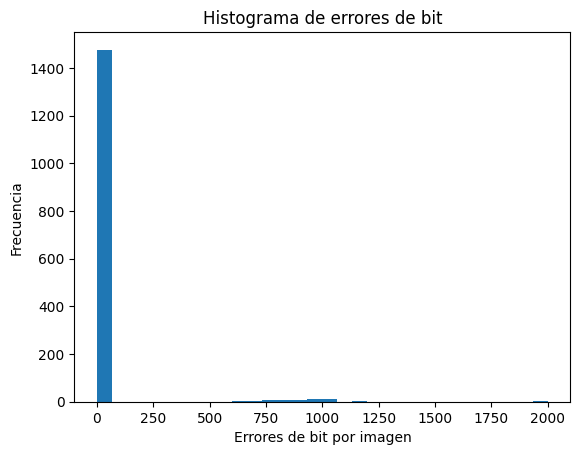

In [39]:
plt.figure()
df['bit_errors'].plot(kind='hist', bins=30)
plt.xlabel('Errores de bit por imagen')
plt.ylabel('Frecuencia')
plt.title('Histograma de errores de bit')
plt.show()


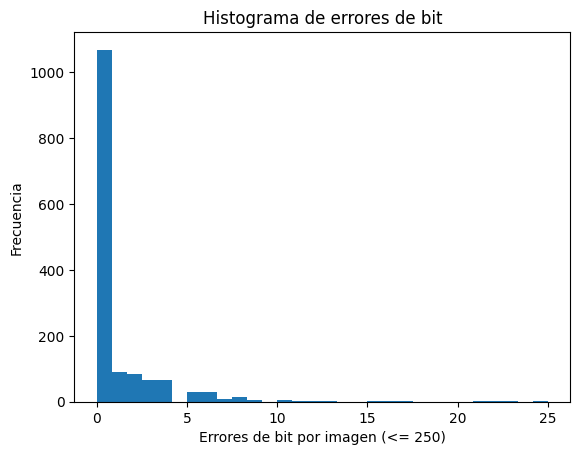

In [53]:
# Errores de bits por replica para cada auto con menos de 250 errores
test_df = df[df['bit_errors'] < 250]


plt.figure()
test_df['bit_errors'].plot(kind='hist', bins=30)
plt.xlabel('Errores de bit por imagen (<= 250)')
plt.ylabel('Frecuencia')
plt.title('Histograma de errores de bit')
plt.show()

## Errores de bit por réplica

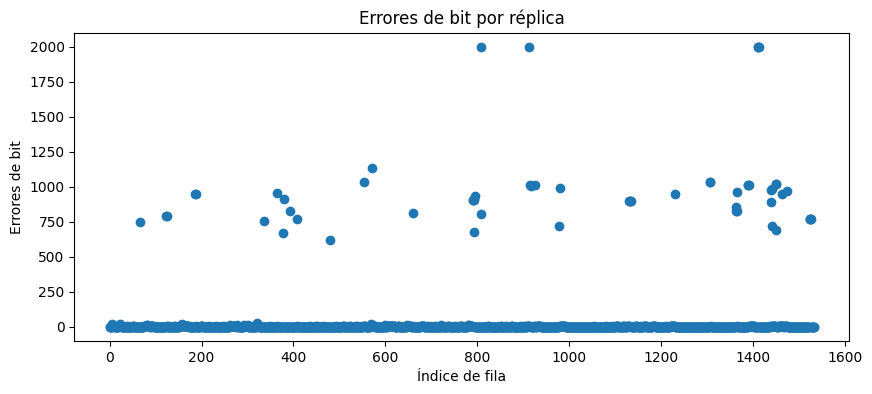

In [40]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df['bit_errors'], marker='o', linestyle='none')
plt.xlabel('Índice de fila')
plt.ylabel('Errores de bit')
plt.title('Errores de bit por réplica')
plt.show()


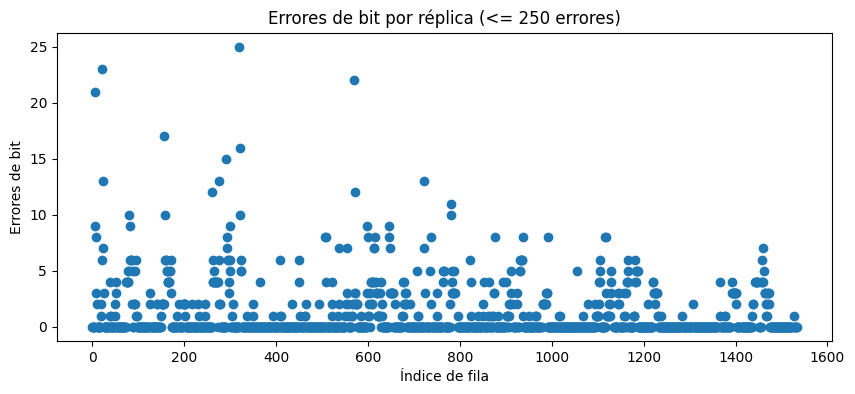

In [52]:
# Errores de bits por replica para cada auto con menos de 250 errores
test_df = df[df['bit_errors'] < 250]

plt.figure(figsize=(10,4))
plt.plot(test_df.index, test_df['bit_errors'], marker='o', linestyle='none')
plt.xlabel('Índice de fila')
plt.ylabel('Errores de bit')
plt.title('Errores de bit por réplica (<= 250 errores)')
plt.show()


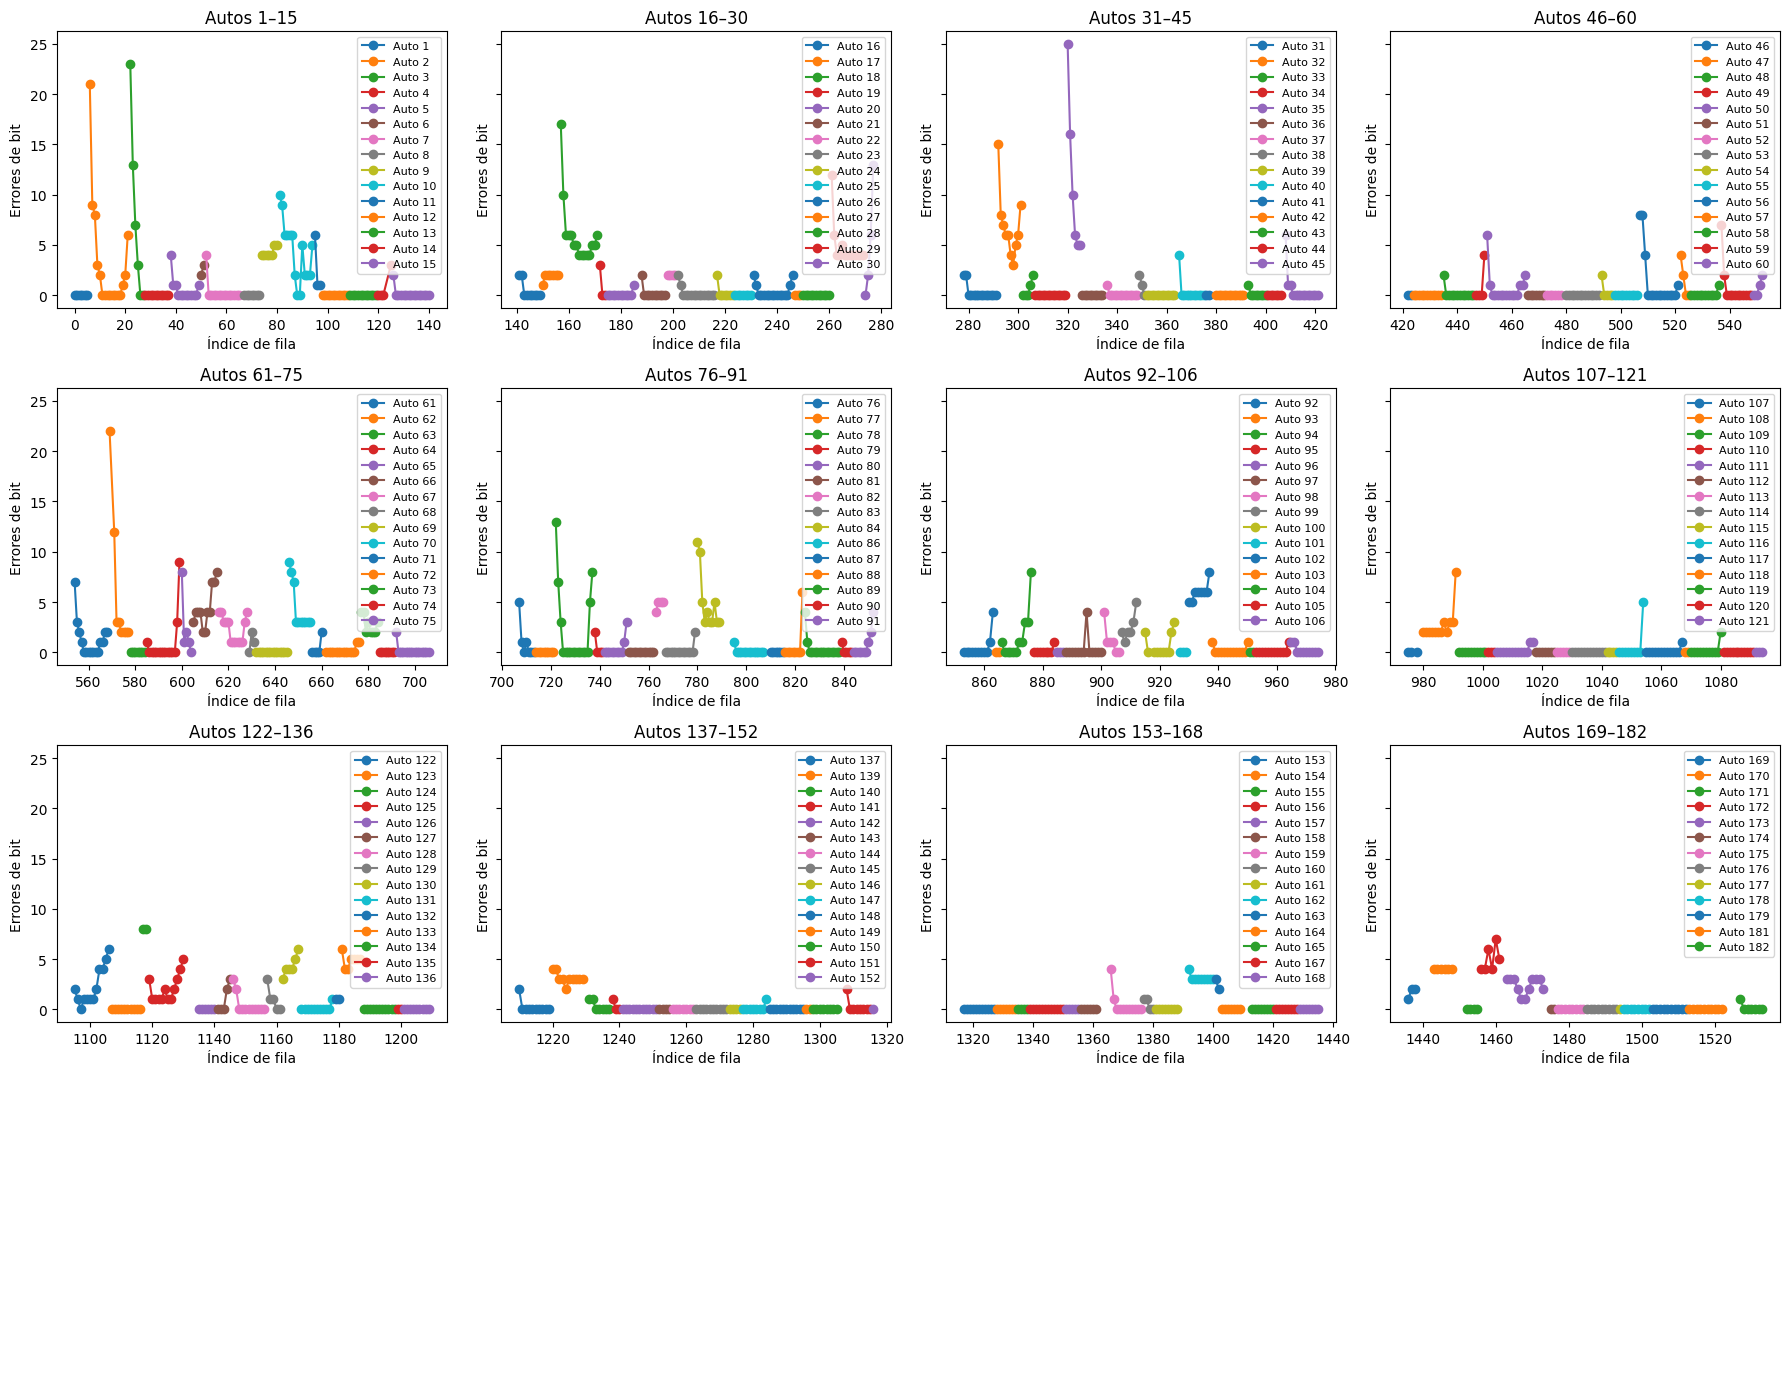

In [51]:
autos = sorted(test_df['num_auto'].unique())[:16*15]  # hasta 240 autos si hay suficientes
fig, axes = plt.subplots(4, 4, figsize=(18, 14), sharey=True)
for idx, ax in enumerate(axes.flat):
    start = idx * 15
    end = start + 15
    if start >= len(autos):
        ax.axis('off')
        continue
    for i in autos[start:end]:
        auto_df = test_df[test_df['num_auto'] == i]
        ax.plot(auto_df.index, auto_df['bit_errors'], marker='o', linestyle='-', label=f'Auto {i}')
    ax.set_title(f'Autos {autos[start]}–{autos[min(end-1, len(autos)-1)]}')
    ax.set_xlabel('Índice de fila')
    ax.set_ylabel('Errores de bit')
    ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

## Imágenes que no cumplen el criterio

In [41]:
# Eliminamos las que tienen 2000 errores, ya que es la imagen inversa
df = df[df['bit_errors'] < 2000]

In [42]:
import numpy as np   # por si no estaba importado

# --- Parámetros de tolerancia ---
BITS_TOTAL = 2000      
max_errors = 100  # máximo de bits erróneos permitidos
max_ber    = max_errors / BITS_TOTAL  # % BER máximo

# --- BER por fila ---
df['bits_total'] = BITS_TOTAL
df['ber'] = df['bit_errors'] / BITS_TOTAL

# --- Criterio de falla ---
fail_df = df[(df['bit_errors'] > max_errors) | (df['ber'] > max_ber)]

print(f'Imágenes que superan el umbral: {len(fail_df)}')
print(f'Total de imágenes: {len(df)}')
print(f'Porcentaje de fallos: {len(fail_df) / len(df) * 100:.2f}%')
display(
    fail_df[['num_auto', 'bw_plate_tx', 'bw_plate_rx',
             'bit_errors', 'ber']]
)


Imágenes que superan el umbral: 53
Total de imágenes: 1529
Porcentaje de fallos: 3.47%


,num_auto,bw_plate_tx,bw_plate_rx,bit_errors,ber
66,64,dataset_yolo/autos_bw/auto064.png,data_12m/autos_bw/auto064_rep01.png,749,0.3745
123,64,dataset_yolo/autos_bw/auto064.png,data_12m/autos_bw/auto064_rep02.png,792,0.3960
124,64,dataset_yolo/autos_bw/auto064.png,data_12m/autos_bw/auto064_rep03.png,790,0.3950
186,53,dataset_yolo/autos_bw/auto053.png,data_12m/autos_bw/auto053_rep01.png,949,0.4745
187,53,dataset_yolo/autos_bw/auto053.png,data_12m/autos_bw/auto053_rep02.png,945,0.4725
335,45,dataset_yolo/autos_bw/auto045.png,data_12m/autos_bw/auto045_rep01.png,755,0.3775
364,104,dataset_yolo/autos_bw/auto104.png,data_12m/autos_bw/auto104_rep01.png,952,0.4760
378,122,dataset_yolo/autos_bw/auto122.png,data_12m/autos_bw/auto122_rep01.png,672,0.3360
379,106,dataset_yolo/autos_bw/auto106.png,data_12m/autos_bw/auto106_rep01.png,910,0.4550
392,107,dataset_yolo/autos_bw/auto107.png,data_12m/autos_bw/auto107_rep01.png,824,0.4120


### Visualización de las primeras 5 imágenes fallidas

Auto 64 – errores: 749


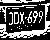

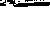

Auto 64 – errores: 792


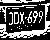

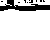

Auto 64 – errores: 790


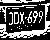

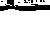

Auto 53 – errores: 949


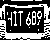

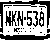

Auto 53 – errores: 945


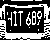

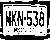

Auto 45 – errores: 755


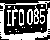

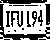

Auto 104 – errores: 952


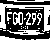

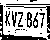

Auto 122 – errores: 672


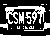

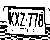

Auto 106 – errores: 910


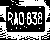

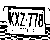

Auto 107 – errores: 824


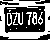

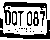

Auto 109 – errores: 773


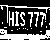

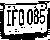

Auto 61 – errores: 622


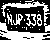

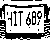

Auto 89 – errores: 1032


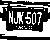

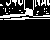

Auto 127 – errores: 1136


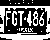

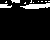

Auto 36 – errores: 810


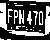

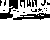

Auto 93 – errores: 902


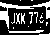

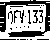

Auto 93 – errores: 902


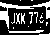

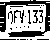

Auto 93 – errores: 902


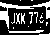

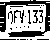

Auto 95 – errores: 676


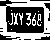

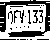

Auto 127 – errores: 934


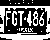

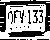

Auto 94 – errores: 805


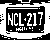

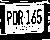

Auto 56 – errores: 1009


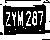

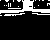

Auto 56 – errores: 1008


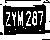

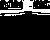

Auto 56 – errores: 1009


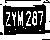

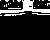

Auto 105 – errores: 718


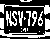

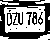

In [43]:
path = 'results/12m/'

for _, row in fail_df.head(25).iterrows():
    print(f"Auto {row['num_auto']} – errores: {row['bit_errors']}")
    display(Image(filename=row['bw_plate_tx']))
    display(Image(filename=path + row['bw_plate_rx']))


In [44]:
# --- Umbral de bits erróneos ---
thr_err = 15

# --- Agrupar por auto y comprobar si alguna réplica cumple ---
auto_status = (
    df.groupby('num_auto')['bit_errors']
      .apply(lambda s: (s < thr_err).any())   # True = tiene al menos una buena
)

# Autos sin réplica “buena”
failed_autos = auto_status[~auto_status]      # False significa que falló
num_failed   = failed_autos.size
num_total    = auto_status.size

print(f'Autos sin ninguna réplica con < {thr_err} errores de bit: '
      f'{num_failed} de {num_total}')

# Mostrar la lista (si quieres verla)
display(failed_autos.index.tolist())


Autos sin ninguna réplica con < 15 errores de bit: 1 de 179


[138]